# Compare datasets: COPER (mortality) vs ICU-Sepsis (MDP)

This notebook summarizes **two different data products** used in this repo:

| Track | Role | Typical time framing |
| --- | --- | --- |
| **COPER** | In-hospital **mortality** prediction from **dense** benchmark tensors | **First 48 hours** of ICU data, **1 h** discretization (mimic3-benchmarks IHM + stock normalizer). |
| **ICU-Sepsis MDP** | Tabular **RL** environment built from a **sepsis** RL table | **Along the ICU stay** (many decision steps); unified build default is **1 h per RL row** (`mdp_rl_bloc_interval_hours` → `sepsis_cohort --bloc-interval-hours`). Hours are **not** stored inside `dynamics.npz`—only discrete state indices and transitions. |

They are **not** the same cohort or sample space: IHM is a broad ICU mortality task; the MDP is sepsis-focused and discrete. Use this notebook for **sanity checks and teaching**, not to assert patient-level alignment without a custom join.

Implementation: `data_mngmt/tools/dataset_compare.py`.


## After `build_data.ipynb` completes

Use this notebook to **sanity-check** artifacts under `data_mngmt/generated/`:

- **COPER pickle** (`paths.json` → `mimic3_mortality`, usually `mortality_coper_<slug>.data`): section *COPER mortality pickle* + feature exploration.
- **Unified build** (`data_mngmt/generated/unified/<slug>/unified_build.json`): next section loads `slug`, compares pickles if present, summarizes **`mdp_params_<slug>/`**, and runs **COPER ↔ MDP** overlap on `mdp_cohort_<slug>.csv`.
- **MDP cohort table**: histograms / columns / `bloc` range (expect `bloc_max` ≈ 79 with 1 h blocs).

If you only want a quick post-build check: run **setup** → **side-by-side** → **Unified build** (`slug = sepsis-60m-h48ihm`) → **MDP cohort**.

For **48h COPER vs 1h MDP blocs** (timestep / gaps / label agreement), run the section **« Cohérence 48h / 1h »** at the end of this notebook.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_coper_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data_mngmt" / "tools" / "dataset_compare.py").is_file():
            return p
    raise RuntimeError("Could not locate COPER repo root.")


REPO = find_coper_repo()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

PKG = REPO / "icu_sepsis" / "icu_sepsis"
if str(PKG) not in sys.path:
    sys.path.insert(0, str(PKG))

from data_mngmt.tools.dataset_compare import (
    compare_mortality_pickles,
    comparison_summary_table,
    sample_mdp_episode_lengths,
    summarize_coper_mortality_dataset,
    summarize_icu_mdp_params_dir,
    summarize_packaged_icu_mdp,
)

print("REPO", REPO)

REPO /home/charlesv/Desktop/StatisitcalGenetics/code/COPER


## Side-by-side framing


In [2]:
import json

# Prefer unified build artifacts so time granularity/window reflects build_data.ipynb output.
# If available, infer latest slug from published marker.
_latest_marker = REPO / "data_mngmt" / "generated" / "icu_sepsis_csv_tables" / "PUBLISHED_FROM_UNIFIED_BUILD.txt"
_latest_slug = None
if _latest_marker.is_file():
    for _line in _latest_marker.read_text(encoding="utf-8").splitlines():
        if _line.startswith("source_rl="):
            _p = Path(_line.split("=", 1)[1].strip())
            _latest_slug = _p.parent.name or None
            break

try:
    _slug = slug  # type: ignore[name-defined]
except Exception:
    _slug = _latest_slug or "sepsis-60m-h48ihm"

_unified_work = REPO / "data_mngmt" / "generated" / "unified" / _slug
_meta_path = _unified_work / "unified_build.json"
_unified_pickle = REPO / "data_mngmt" / "generated" / f"mortality_coper_{_slug}.data"
_mdp_dir = _unified_work / f"mdp_params_{_slug}"

coper_stats = summarize_coper_mortality_dataset(_unified_pickle if _unified_pickle.is_file() else None)
mdp_stats = summarize_icu_mdp_params_dir(_mdp_dir) if _mdp_dir.is_dir() else summarize_packaged_icu_mdp()
rows = comparison_summary_table(coper=coper_stats, mdp=mdp_stats)

# Overwrite time framing with explicit contract values when available.
if _meta_path.is_file():
    _meta = json.loads(_meta_path.read_text(encoding="utf-8"))
    _pc = _meta.get("pipeline_contract", {})
    _c_step = _pc.get("coper_timestep_hours")
    _c_h = _pc.get("coper_horizon_hours")
    _m_step = _pc.get("mdp_bloc_interval_hours_assumed")

    if _c_step is not None and _c_h is not None:
        rows["Typical time framing"] = (
            f"first {_c_h:g}h of ICU stay, {_c_step:g}h discretization (build slug {_slug})",
            rows["Typical time framing"][1],
        )
    if _m_step is not None:
        rows["Typical time framing"] = (
            rows["Typical time framing"][0],
            f"decision epochs along ICU trajectory, {_m_step:g}h per RL row (build slug {_slug})",
        )

pd.DataFrame(
    {
        "COPER (IHM tensors)": {k: v[0] for k, v in rows.items()},
        "ICU-Sepsis MDP": {k: v[1] for k, v in rows.items()},
    }
)

,COPER (IHM tensors),ICU-Sepsis MDP
Representation,Dense time series tensors (per stay),Discrete states + tabular dynamics
Benchmark / cohort,in-hospital mortality (IHM),ICU-Sepsis tabular MDP (custom build directory)
Typical time framing,"first 48h of ICU stay, 1h discretization (buil...","decision epochs along ICU trajectory, 1h per R..."
Train-scale summary,"(2850, 48, 76)",723 states × 25 actions


## COPER mortality pickle (`paths.json` → `mimic3_mortality`)


In [3]:
coper_stats = summarize_coper_mortality_dataset()
pd.Series({k: coper_stats[k] for k in ("exists", "artifact", "X_train_shape", "X_val_shape", "X_test_shape") if k in coper_stats})

if coper_stats.get("splits"):
    display(pd.DataFrame(coper_stats["splits"]))

coper_stats.get("details", {})

,split,n,positive,rate
0,train,2850,747,0.262105
1,val,649,188,0.289676
2,test,618,149,0.241100


{'format': 'mimic3-benchmarks in-hospital-mortality + discretizer/normalizer',
 'timestep': 1.0,
 'period_length': 48.0,
 'horizon_mode': 'first_n_hours',
 'shapes': {'train': (2850, 48, 76),
  'val': (649, 48, 76),
  'test': (618, 48, 76)},
 'build_slug': 'sepsis-60m-h48ihm',
 'sepsis_cohort': True,
 'timestep_minutes': 60,
 'timestep_hours': 1.0,
 'horizon_hours': 48.0,
 'label': 'in_hospital_mortality',
 'label_description': 'Binary in-hospital mortality (IHM) from mimic3-benchmarks listfiles; aligned with MIMIC ADMISSIONS.HOSPITAL_EXPIRE_FLAG for MDP cohort column mortality_inhospital.',
 'physionet_mimic_root': '/home/charlesv/Desktop/StatisitcalGenetics/MIMIC/physionet.org/files/mimiciii/1.4',
 'benchmark_workdir': '/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm',
 'icustay_id': {'train': array([203959, 225740, 281156, ..., 248569, 219918, 203186], shape=(2850,)),
  'val': array([288621, 292229, 276442, 280700, 235141, 291036,

## COPER: feature exploration (from mimic3-benchmarks header)

This section reproduces the key parts of `mortality_pickle_display.ipynb` inside this single notebook:

- derive `FEATURE_NAMES` from the **mimic3-benchmarks Discretizer header** (76 channels)
- plot **feature–feature correlation** on time-averaged tensors (subsample)
- compute **point-biserial** correlation between the IHM label and time-averaged features


IHM root for header: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/in-hospital-mortality
n_features: 76
COPER pickle: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data


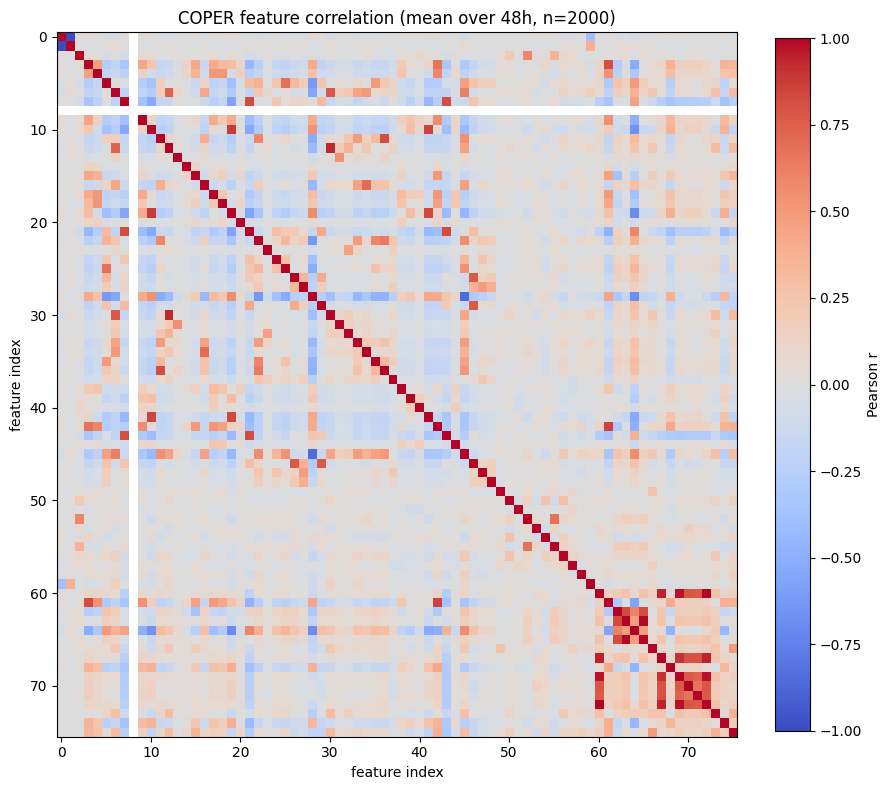

/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,j,feature,r_pb,p_value
75,75,mask->pH,0.201981,7.416939e-20
30,30,Glascow coma scale total->3,0.183114,1.533655e-16
12,12,Glascow coma scale motor response->1 No Response,0.183040,1.577708e-16
55,55,Systolic blood pressure,-0.179854,5.297782e-16
28,28,Glascow coma scale total->15,-0.163316,2.003717e-13
6,6,Glascow coma scale eye opening->1 No Response,0.156010,2.289377e-12
45,45,Glascow coma scale verbal response->1.0 ET/Trach,0.142485,1.545577e-10
15,15,Glascow coma scale motor response->No response,0.136910,7.848677e-10
19,19,Glascow coma scale motor response->Obeys Commands,-0.133328,2.155945e-09
43,43,Glascow coma scale verbal response->5 Oriented,-0.127034,1.193360e-08


In [4]:
from __future__ import annotations

import pickle
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from scipy.stats import pointbiserialr
except Exception:
    pointbiserialr = None

from data_mngmt import mortality_pickle_path
from data_mngmt.mimic.coper_mimic3_export import default_mimic3_repo

# --- Resolve IHM data root to derive FEATURE_NAMES ---
# Prefer unified build workdir if it exists; fallback to mimic3-benchmarks repo default.

timestep_hours = 1.0
period_length_hours = 48.0

_mimic3_repo = default_mimic3_repo()
if str(_mimic3_repo) not in sys.path:
    sys.path.insert(0, str(_mimic3_repo))

from mimic3benchmark.readers import InHospitalMortalityReader  # noqa: E402
from mimic3models.preprocessing import Discretizer  # noqa: E402

_run_date = date.today().isoformat()

# Use unified slug if defined in the unified section above; otherwise default.
try:
    _slug = slug  # type: ignore[name-defined]
except Exception:
    _slug = "sepsis-60m-h48ihm"

_unified_ihm_root = REPO / "data_mngmt" / "generated" / "unified" / _slug / "in-hospital-mortality"
_default_ihm_root = _mimic3_repo / "data" / "in-hospital-mortality"

ihm_root = _unified_ihm_root if _unified_ihm_root.is_dir() else _default_ihm_root
print("IHM root for header:", ihm_root)

train_reader = InHospitalMortalityReader(
    dataset_dir=str(ihm_root / "train"),
    listfile=str(ihm_root / "train_listfile.csv"),
    period_length=period_length_hours,
)
discretizer = Discretizer(
    timestep=timestep_hours,
    store_masks=True,
    impute_strategy="previous",
    start_time="zero",
)
_n_train = train_reader.get_number_of_examples()
if _n_train < 1:
    raise RuntimeError(
        f"train listfile has no examples at {ihm_root / 'train_listfile.csv'}; "
        "run unified build (build_data.ipynb) or point ihm_root to a populated mimic3-benchmarks IHM folder."
    )
_, header_str = discretizer.transform(train_reader.read_example(0)["X"])
FEATURE_NAMES = header_str.split(",")
print("n_features:", len(FEATURE_NAMES))


# --- Load COPER mortality pickle (prefer unified, else default paths.json) ---
try:
    _pickle_path = unified_pickle if unified_pickle.is_file() else default_pickle  # type: ignore[name-defined]
except Exception:
    # fallback to whatever summarize_coper_mortality_dataset() uses
    _pickle_path = Path(mortality_pickle_path())

assert _pickle_path.is_file(), f"Missing COPER pickle: {_pickle_path}"
print("COPER pickle:", _pickle_path)

with open(_pickle_path, "rb") as f:
    details, X_train, y_train, X_val, y_val, X_test, y_test, _ = pickle.load(f)


# --- Feature–feature correlation (subsample) ---
rng = np.random.default_rng(0)
X = np.asarray(X_train)
y = np.asarray(y_train).reshape(-1)

nmax = 2000
if X.shape[0] > nmax:
    idx = rng.choice(X.shape[0], size=nmax, replace=False)
    Xsamp = X[idx]
    ysamp = y[idx]
else:
    Xsamp = X
    ysamp = y

feat = Xsamp.mean(axis=1)  # (n, 76)
df_f = pd.DataFrame(feat, columns=FEATURE_NAMES)
C = df_f.corr().values

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
ax.set_title(f"COPER feature correlation (mean over 48h, n={min(nmax, X.shape[0])})")
ax.set_xlabel("feature index")
ax.set_ylabel("feature index")
plt.tight_layout()
plt.show()


# --- Outcome vs feature (point-biserial on mean per stay) ---
if pointbiserialr is None:
    print("scipy not available: skip point-biserial correlations")
else:
    rows = []
    for j, name in enumerate(FEATURE_NAMES):
        xj = feat[:, j]
        try:
            rpb, p = pointbiserialr(ysamp, xj)
        except Exception:
            rpb, p = np.nan, np.nan
        rows.append({"j": j, "feature": name, "r_pb": float(rpb), "p_value": float(p)})

    out = pd.DataFrame(rows)
    out = out.reindex(out["r_pb"].abs().sort_values(ascending=False).index)
    display(out.head(15))

## Packaged ICU-Sepsis MDP (`icu_sepsis/.../envs/assets/dynamics.npz`)


In [5]:
mdp_stats = summarize_packaged_icu_mdp()
pd.Series(
    {
        k: mdp_stats[k]
        for k in (
            "exists",
            "artifact",
            "n_states_mdp",
            "n_actions_mdp",
            "d_0_entropy_nat",
            "d_0_support_states",
            "d_0_top5_mass",
        )
        if k in mdp_stats
    }
)

mdp_stats.get("metadata", {})

{'n_states': 750,
 'n_actions': 25,
 'r_survive': 1.0,
 'r_death': 0.0,
 'threshold': 20,
 'seed': 0,
 'action_map_method': 'uniform_unweighted'}

## MDP cohort table exploration (`mdp_cohort_<slug>.csv`)

When the unified build has produced `data_mngmt/generated/unified/<slug>/mdp_cohort_<slug>.csv`, this section:

- summarizes **rows**, **unique ICU stays**, and **bloc coverage**
- plots **episode length proxy** = number of blocs per `icustayid`
- computes **feature–feature correlations** on numeric columns (subset)
- computes **point-biserial** correlations between `mortality_inhospital` and numeric features


MDP cohort CSV: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv exists= True
rows: 249032
unique icustays: 4790
bloc min/max: 1.0 79.0


,icustayid,n_blocs
count,4790.000000,4790.000000
mean,250013.987474,51.989979
std,28770.144081,21.216075
min,200003.000000,1.000000
25%,225345.750000,37.000000
50%,250504.000000,53.000000
75%,274863.500000,75.000000
max,299955.000000,79.000000


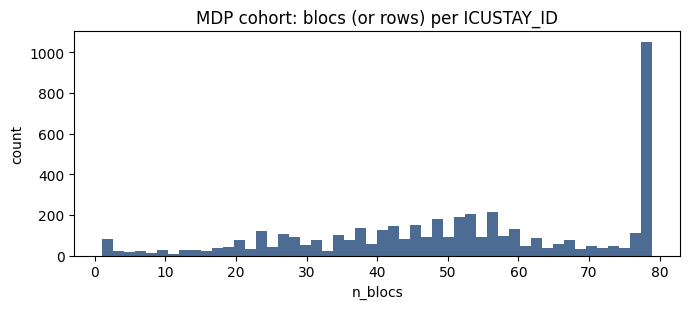

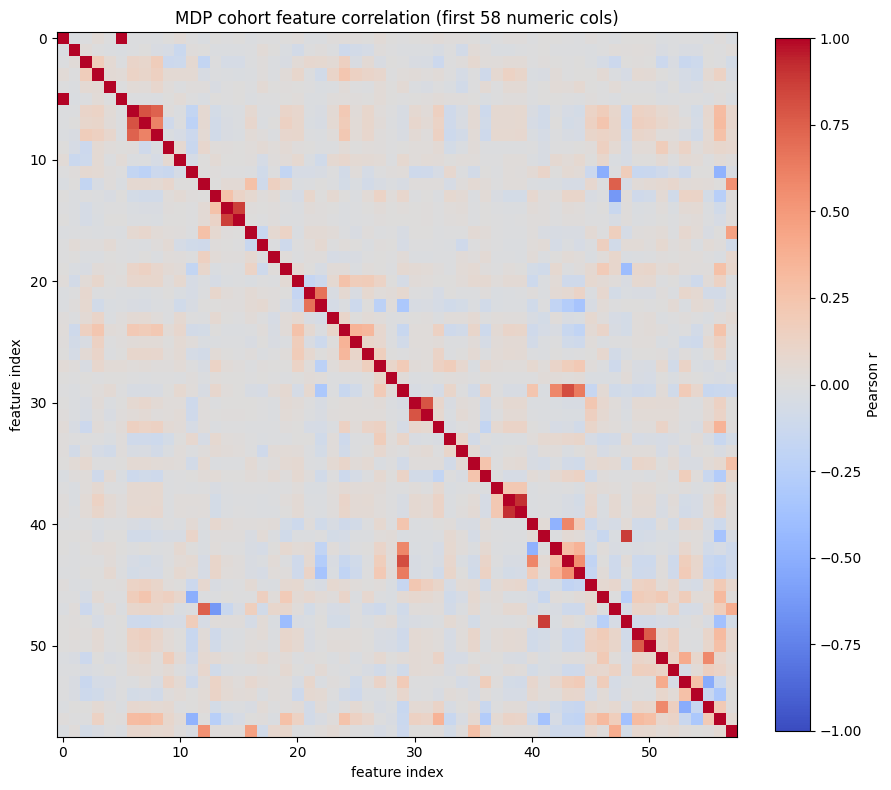

,feature,r_pb,p_value,n
6,died_in_hosp,0.982828,0.0,249032
7,died_within_48h_of_out_time,0.798207,0.0,249032
8,mortality_90d,0.726746,0.0,249032
56,SOFA,0.299122,0.0,249032
24,BUN,0.202056,0.0,249032
46,mechvent,0.176304,0.0,249032
11,GCS,-0.175053,0.0,249032
32,Total_bili,0.147978,0.0,249032
49,median_dose_vaso,0.127744,0.0,249032
3,elixhauser,0.122690,0.0,249032


In [6]:
import numpy as np
import pandas as pd

try:
    from scipy.stats import pointbiserialr
except Exception:
    pointbiserialr = None

# Reuse slug if already defined
try:
    _slug = slug  # type: ignore[name-defined]
except Exception:
    _slug = "sepsis-60m-h48ihm"

_unified_work = REPO / "data_mngmt" / "generated" / "unified" / _slug
_mdp_csv = _unified_work / f"mdp_cohort_{_slug}.csv"

print("MDP cohort CSV:", _mdp_csv, "exists=", _mdp_csv.is_file())

if not _mdp_csv.is_file():
    print("No mdp_cohort CSV yet — run unified build with BUILD_MDP=True to generate it.")
else:
    df = pd.read_csv(_mdp_csv)
    icu_col = next((c for c in ("icustayid", "ICUSTAY_ID", "icustay_id") if c in df.columns), None)
    bloc_col = next((c for c in ("bloc", "BLOC") if c in df.columns), None)
    y_col = "mortality_inhospital" if "mortality_inhospital" in df.columns else None

    if icu_col is None:
        raise KeyError(f"No icustay id column found in {list(df.columns)[:30]}")

    print("rows:", len(df))
    print("unique icustays:", df[icu_col].nunique())
    if bloc_col is not None:
        print("bloc min/max:", df[bloc_col].min(), df[bloc_col].max())

    # blocs per stay
    if bloc_col is not None:
        per = df.groupby(icu_col)[bloc_col].nunique().rename("n_blocs").reset_index()
    else:
        per = df.groupby(icu_col).size().rename("n_rows").reset_index()

    display(per.describe(include="all"))

    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 3.2))
    plt.hist(per.iloc[:, 1].to_numpy(), bins=50, color="#2c5282", alpha=0.85)
    plt.title("MDP cohort: blocs (or rows) per ICUSTAY_ID")
    plt.xlabel(per.columns[1])
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    # Numeric feature correlation (subset)
    num = df.select_dtypes(include=["number"]).copy()
    # Drop obvious ids and outcome
    for c in (icu_col, bloc_col, y_col):
        if c and c in num.columns:
            num = num.drop(columns=[c])

    if num.shape[1] == 0:
        print("No numeric feature columns found for correlation.")
    else:
        cols = list(num.columns)
        max_cols = 60
        if len(cols) > max_cols:
            cols = cols[:max_cols]
            num = num[cols]

        C = num.corr().values
        fig, ax = plt.subplots(figsize=(9, 8))
        im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
        ax.set_title(f"MDP cohort feature correlation (first {len(cols)} numeric cols)")
        ax.set_xlabel("feature index")
        ax.set_ylabel("feature index")
        plt.tight_layout()
        plt.show()

        # Outcome correlations
        if y_col is None:
            print("No mortality_inhospital column found; skip outcome correlations.")
        elif pointbiserialr is None:
            print("scipy not available: skip point-biserial correlations")
        else:
            y = df[y_col].astype(int).to_numpy()
            rows = []
            for c in cols:
                x = df[c].to_numpy()
                # drop NaNs pairwise
                m = np.isfinite(x) & np.isfinite(y)
                if m.sum() < 10:
                    continue
                try:
                    rpb, p = pointbiserialr(y[m], x[m])
                except Exception:
                    rpb, p = np.nan, np.nan
                rows.append({"feature": c, "r_pb": float(rpb), "p_value": float(p), "n": int(m.sum())})

            out = pd.DataFrame(rows)
            if len(out):
                out = out.reindex(out["r_pb"].abs().sort_values(ascending=False).index)
                display(out.head(20))
            else:
                print("No valid feature correlations computed.")


## MDP episode lengths (Monte Carlo)

Empirical step counts under **random** vs **expert** policy until absorption or `max_episode_steps` (see `icu_sepsis` constants). This is **not** the same unit as COPER’s 48 time bins.


In [7]:
import importlib

import icu_sepsis  # noqa: F401

N_MC = 800  # increase for smoother histograms
rng_seed = 0

rand_len = sample_mdp_episode_lengths(
    N_MC, seed=rng_seed, policy="random", return_lengths=True
)
exp_len = sample_mdp_episode_lengths(
    N_MC, seed=rng_seed + 1, policy="expert", return_lengths=True
)
_r = {k: rand_len[k] for k in rand_len if k != "lengths"}
_e = {k: exp_len[k] for k in exp_len if k != "lengths"}
pd.DataFrame({"random_policy": _r, "expert_policy": _e})

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


,random_policy,expert_policy
n_episodes,800,800
policy,random,expert
env_id,Sepsis/ICU-Sepsis-v2,Sepsis/ICU-Sepsis-v2
length_mean,9.85375,9.65
length_std,9.898099,9.9106
length_median,6.0,7.0
length_p90,24.0,21.0
length_max,63,83
truncated_fraction,0.0,0.0


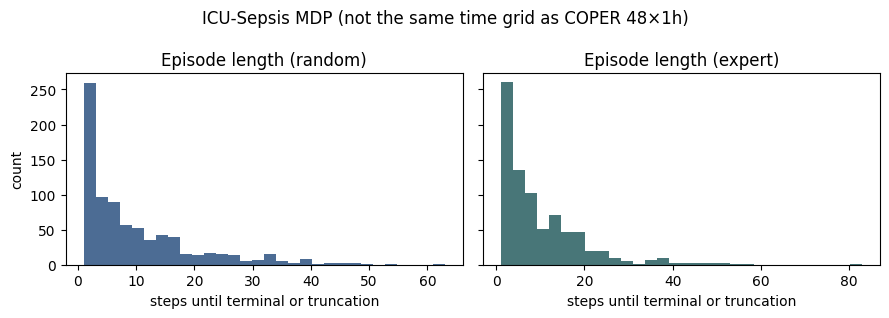

In [8]:
import matplotlib.pyplot as plt

lr = rand_len["lengths"]
le = exp_len["lengths"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
axes[0].hist(lr, bins=30, color="#2c5282", alpha=0.85)
axes[0].set_title("Episode length (random)")
axes[1].hist(le, bins=30, color="#285e61", alpha=0.85)
axes[1].set_title("Episode length (expert)")
for ax in axes:
    ax.set_xlabel("steps until terminal or truncation")
axes[0].set_ylabel("count")
fig.suptitle("ICU-Sepsis MDP (not the same time grid as COPER 48×1h)")
fig.tight_layout()
plt.show()

## Unified build (`pipeline.build_data` / `python -m data_mngmt`)

Set **`slug`** to match your run (default pattern: `sepsis-60m-h48ihm` or `all-60m-h48ihm`). Artifacts live under `data_mngmt/generated/mortality_coper_<slug>.data` and `data_mngmt/generated/unified/<slug>/`.


unified: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data exists= True
default (paths.json mimic3_mortality): /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data exists= True


{'cohort_prepared': '/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv',
 'params_dir': '/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_params_sepsis-60m-h48ihm',
 'outcome_column': 'mortality_inhospital'}

,split,n_unified,rate_unified,n_default,rate_default
0,train,2850,0.262105,2850,0.262105
1,val,649,0.289676,649,0.289676
2,test,618,0.241100,618,0.241100


unified_details    {'format': 'mimic3-benchmarks in-hospital-mort...
default_details    {'format': 'mimic3-benchmarks in-hospital-mort...
dtype: object

artifact              /home/charlesv/Desktop/StatisitcalGenetics/cod...
exists                                                             True
task                    ICU-Sepsis tabular MDP (custom build directory)
typical_setup         /home/charlesv/Desktop/StatisitcalGenetics/cod...
metadata              {'n_states': 750, 'n_actions': 25, 'r_survive'...
n_states_mdp                                                        723
n_actions_mdp                                                        25
d_0_entropy_nat                                                5.456302
d_0_support_states                                                  595
d_0_top5_mass                                                  0.132563
gamma_env_default                                                   1.0
dtype: object


Using COPER pickle: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/mortality_coper_sepsis-60m-h48ihm.data
MDP cohort CSV: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/data_mngmt/generated/unified/sepsis-60m-h48ihm/mdp_cohort_sepsis-60m-h48ihm.csv exists= True


n_coper                4117.000000
n_mdp_cohort_unique    4790.000000
n_intersection         2702.000000
coper_in_mdp_frac         0.656303
dtype: float64

,icustayid,min_bloc,max_bloc,n_unique
0,200003,1,34,22
1,200033,1,79,79
2,200063,1,55,54
3,200075,1,68,53
4,200087,1,78,65


,icustayid,n,min,max,step_ok,step_unique
0,200003,22,1,34,False,"[1, 13]"
1,200033,79,1,79,True,[1]
2,200063,54,1,55,False,"[1, 2]"
3,200075,53,1,68,False,"[1, 3, 4, 5, 7]"
4,200087,65,1,78,False,"[1, 4, 11]"



Heuristic mapping suggestion:
- if bloc starts at 0: map COPER t -> bloc = t
- if bloc starts at 1: map COPER t -> bloc = t + 1
sample min_bloc values: [1, 1, 1, 1, 1]


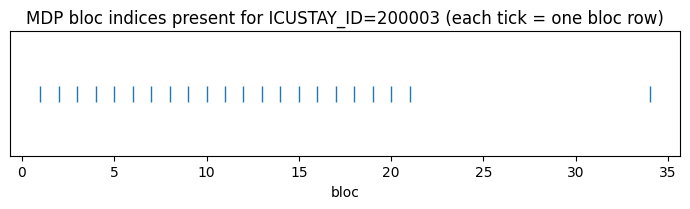

In [ ]:
import json
import pickle

import numpy as np

from data_mngmt import load_paths, mortality_pickle_path
from data_mngmt.contracts.alignment_utils import alignment_summary_coper_mdp

paths = load_paths()

# Prefer explicit slug if defined; otherwise infer latest from publish marker.
_latest_marker = REPO / "data_mngmt" / "generated" / "icu_sepsis_csv_tables" / "PUBLISHED_FROM_UNIFIED_BUILD.txt"
_latest_slug = None
if _latest_marker.is_file():
    for _line in _latest_marker.read_text(encoding="utf-8").splitlines():
        if _line.startswith("source_rl="):
            _p = Path(_line.split("=", 1)[1].strip())
            _latest_slug = _p.parent.name or None
            break

try:
    slug = slug  # type: ignore[name-defined]
except Exception:
    slug = _latest_slug or "sepsis-60m-h48ihm"

unified_work = REPO / "data_mngmt" / "generated" / "unified" / slug
unified_pickle = REPO / "data_mngmt" / "generated" / f"mortality_coper_{slug}.data"
meta_path = unified_work / "unified_build.json"
default_pickle = Path(mortality_pickle_path())

print("unified:", unified_pickle, "exists=", unified_pickle.is_file())
print("default (paths.json mimic3_mortality):", default_pickle, "exists=", default_pickle.is_file())
if meta_path.is_file():
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    display(meta.get("mdp", {}))

if unified_pickle.is_file() and default_pickle.is_file():
    cmp = compare_mortality_pickles(unified_pickle, default_pickle)
    display(
        pd.DataFrame(
            {
                "split": [r["split"] for r in cmp["a_splits"]],
                "n_unified": [r["n"] for r in cmp["a_splits"]],
                "rate_unified": [r["rate"] for r in cmp["a_splits"]],
                "n_default": [r["n"] for r in cmp["b_splits"]],
                "rate_default": [r["rate"] for r in cmp["b_splits"]],
            }
        )
    )
    display(pd.Series({"unified_details": cmp["a_details"], "default_details": cmp["b_details"]}))

mdp_dir = unified_work / f"mdp_params_{slug}"
if mdp_dir.is_dir():
    display(pd.Series(summarize_icu_mdp_params_dir(mdp_dir)))


# --- COPER ↔ MDP sanity check on (ICUSTAY_ID, t) / bloc conventions ---
# Goal: on a handful of stays, check that the RL table `bloc` index behaves like an hourly grid
# (monotone, roughly contiguous) and decide whether `bloc` is 0- or 1-indexed relative to COPER t=0..47.

pickle_path = unified_pickle if unified_pickle.is_file() else default_pickle
mdp_cohort_csv = unified_work / f"mdp_cohort_{slug}.csv"

print("\nUsing COPER pickle:", pickle_path)
print("MDP cohort CSV:", mdp_cohort_csv, "exists=", mdp_cohort_csv.is_file())

if mdp_cohort_csv.is_file() and pickle_path.is_file():
    # 1) Overlap summary (stay-level)
    summ = alignment_summary_coper_mdp(pickle_path, mdp_cohort_csv)
    display(pd.Series(summ.get("overlap_by_split", {}).get("all_splits", {})))

    # 2) Inspect bloc indexing for a few overlapping stays
    with open(pickle_path, "rb") as f:
        details = pickle.load(f)[0]
    icu = details.get("icustay_id", {})
    coper_all = set()
    for split in ("train", "val", "test"):
        arr = np.asarray(icu.get(split, [])).reshape(-1)
        if arr.size:
            coper_all |= set(int(x) for x in arr.astype(np.int64).tolist() if int(x) >= 0)

    df = pd.read_csv(mdp_cohort_csv)
    icu_col = next((c for c in ("icustayid", "ICUSTAY_ID", "icustay_id") if c in df.columns), None)
    bloc_col = next((c for c in ("bloc", "BLOC") if c in df.columns), None)
    if icu_col is None or bloc_col is None:
        raise KeyError(f"Need icustay and bloc columns; have: {list(df.columns)[:30]}")

    df[icu_col] = df[icu_col].astype(int)
    # mimic_sepsis typically uses integer `bloc` (often 1-indexed); coerce safely
    df[bloc_col] = pd.to_numeric(df[bloc_col], errors="coerce").astype("Int64")

    overlap = sorted(list(coper_all & set(df[icu_col].unique())))
    if not overlap:
        print("No ICUSTAY_ID overlap between COPER pickle and mdp_cohort CSV.")
    else:
        sample = overlap[:5]
        g = df[df[icu_col].isin(sample)].dropna(subset=[bloc_col]).copy()

        # summary per stay
        by = (
            g.groupby(icu_col)[bloc_col]
            .agg(
                min_bloc="min",
                max_bloc="max",
                n_unique=lambda s: int(s.nunique()),
            )
            .reset_index()
        )
        display(by)

        # check contiguity / step size on the sample
        def _steps(blocs: np.ndarray) -> dict[str, object]:
            b = np.sort(np.unique(blocs[~pd.isna(blocs)].astype(int)))
            if len(b) <= 1:
                return {
                    "n": int(len(b)),
                    "min": int(b[0]) if len(b) else None,
                    "max": int(b[-1]) if len(b) else None,
                    "step_ok": None,
                    "step_unique": [],
                }
            d = np.diff(b)
            return {
                "n": int(len(b)),
                "min": int(b[0]),
                "max": int(b[-1]),
                "step_ok": bool(np.all(d == 1)),
                "step_unique": sorted(set(int(x) for x in np.unique(d))),
            }

        step_rows = []
        for icu_id in sample:
            blocs = g.loc[g[icu_col] == icu_id, bloc_col].to_numpy()
            step_rows.append({icu_col: int(icu_id), **_steps(blocs)})
        display(pd.DataFrame(step_rows))

        # heuristic mapping suggestion for COPER t=0..47
        # If min_bloc is 0 in most stays → use bloc=t; if min_bloc is 1 → bloc=t+1.
        mins = by["min_bloc"].astype(int).tolist()
        print("\nHeuristic mapping suggestion:")
        print("- if bloc starts at 0: map COPER t -> bloc = t")
        print("- if bloc starts at 1: map COPER t -> bloc = t + 1")
        print("sample min_bloc values:", mins)

        # quick visual: bloc coverage for the first sample stay
        icu0 = sample[0]
        b0 = np.sort(
            np.unique(g.loc[g[icu_col] == icu0, bloc_col].dropna().astype(int).to_numpy())
        )
        try:
            import matplotlib.pyplot as plt

            plt.figure(figsize=(7, 2.2))
            plt.plot(b0, np.zeros_like(b0), "|", markersize=12)
            plt.yticks([])
            plt.title(
                f"MDP bloc indices present for ICUSTAY_ID={icu0} (each tick = one bloc row)"
            )
            plt.xlabel("bloc")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print("Plot skipped:", e)
else:
    print("\nSkip alignment check: need both mdp_cohort_<slug>.csv and a COPER pickle.")

## Cohérence 48h / 1h après `build_data.ipynb`

Vérifications **quantitatives** sur les artefacts `data_mngmt/generated/` :

- **`unified_build.json`** : horizon COPER, pas de temps, résumé MDP (`bloc_min` / `bloc_max`).
- **Tenseurs COPER** : forme `(N, 48, F)` et métadonnées `period_length` / `timestep_hours`.
- **Table MDP** : les `bloc` commencent à 1 pour chaque séjour, mais une **majorité** des séjours ont des **sauts** (`diff(bloc) > 1`) : heures sans ligne dans la table RL (comportement attendu de `mimic_sepsis`, pas une grille dense 1…T).
- **Fenêtre 48h** : parmi les `ICUSTAY_ID` présents dans le pickle COPER, seuls une partie ont une ligne pour **chaque** bloc 1…48 (séjours courts ou trous) — à distinguer du tenseur IHM qui garde **48 bins** avec masques.
- **Labels** : accord entre `y` du pickle (IHM mimic3-benchmarks) et `mortality_inhospital` sur l’intersection (quelques désaccords possibles : définitions / bords de cas).

La cellule suivante recharge pickle + CSV ; exécution ~ quelques secondes sur ~250k lignes.

In [10]:
from __future__ import annotations

import json
import pickle

import numpy as np
import pandas as pd

try:
    _slug = slug  # type: ignore[name-defined]
except Exception:
    _slug = "sepsis-60m-h48ihm"

_unified_work = REPO / "data_mngmt" / "generated" / "unified" / _slug
_meta = _unified_work / "unified_build.json"
_pickle = REPO / "data_mngmt" / "generated" / f"mortality_coper_{_slug}.data"
_mdp_csv = _unified_work / f"mdp_cohort_{_slug}.csv"
_align_json = _unified_work / f"coper_mdp_alignment_{_slug}.json"

print("=== unified_build.json (extrait) ===")
if _meta.is_file():
    meta = json.loads(_meta.read_text(encoding="utf-8"))
    pc = meta.get("pipeline_contract", {})
    print("coper_timestep_hours:", pc.get("coper_timestep_hours"), "| coper_horizon_hours:", pc.get("coper_horizon_hours"))
    print("mdp_bloc_interval_hours_assumed:", pc.get("mdp_bloc_interval_hours_assumed"))
    msum = meta.get("mdp_cohort_summary", {})
    print("mdp_cohort_summary bloc_min/max:", msum.get("bloc_min"), msum.get("bloc_max"), "| rows_read (sample cap):", msum.get("rows_read"))
    d = (meta.get("coper_pickle", {}).get("details") or {})
    print("pickle train shape:", (d.get("shapes") or {}).get("train"), "| timestep_hours:", d.get("timestep_hours"), "| period_length:", d.get("period_length"))
else:
    print("missing", _meta)

print("\n=== COPER tenseurs (pickle) ===")
det = None
if _pickle.is_file():
    with open(_pickle, "rb") as f:
        det, Xt, yt, Xv, yv, Xte, yte, _ = pickle.load(f)
    print("X_train shape:", getattr(Xt, "shape", None), "| period_length:", det.get("period_length"), "| timestep_hours:", det.get("timestep_hours"))
else:
    print("missing", _pickle)

print("\n=== MDP cohort: régularité des blocs (triés par séjour) ===")
if not _mdp_csv.is_file():
    print("missing", _mdp_csv)
    df = None
else:
    df = pd.read_csv(_mdp_csv)
    iced = "icustayid"
    n_stays = int(df[iced].nunique())
    strict = starts1 = 0
    max_jump = 0
    for _, g in df.groupby(iced, sort=False):
        s = np.sort(g["bloc"].to_numpy(dtype=float))
        if len(s) == 0:
            continue
        if int(s[0]) == 1:
            starts1 += 1
        if len(s) == 1:
            strict += 1
        else:
            dbl = np.diff(s)
            if bool(np.all(dbl == 1)):
                strict += 1
            max_jump = max(max_jump, int(np.max(dbl)))
    print(f"stays={n_stays}, bloc starts at 1: {starts1}/{n_stays}")
    print(f"strict consecutive +1 between sorted blocs: {strict}/{n_stays} (remainder = gaps / missing hours)")
    print(f"max single-step bloc jump: {max_jump}")

id_y: dict[int, float] = {}
c_ids: set[int] = set()
if det is not None:
    icu = det["icustay_id"]
    for ids, ys in [(icu["train"], yt), (icu["val"], yv), (icu["test"], yte)]:
        for i, y in zip(np.asarray(ids).reshape(-1), np.asarray(ys).reshape(-1)):
            id_y[int(i)] = float(y)
    c_ids = set(id_y.keys())

print("\n=== COPER stays: couverture blocs 1..48 dans la table MDP ===")
if det is not None and df is not None:
    sub = df[df["icustayid"].isin(c_ids)].groupby("icustayid", sort=False)
    full48 = 0
    for _, grp in sub:
        bl = set(grp["bloc"].astype(int))
        if all(b in bl for b in range(1, 49)):
            full48 += 1
    print(f"have a row for every bloc in {{1..48}}: {full48} / {len(c_ids)} (COPER union train∪val∪test)")
else:
    print("skip (need pickle + mdp_cohort CSV)")

print("\n=== Labels: IHM pickle y vs mortality_inhospital (intersection) ===")
if det is not None and df is not None and "mortality_inhospital" in df.columns:
    inter = c_ids & set(df["icustayid"].astype(int).unique())
    agree = disagree = 0
    sample_bad: list[tuple[int, bool, int]] = []
    for iid in inter:
        cy = id_y[iid] >= 0.5
        m = int(df.loc[df["icustayid"] == iid, "mortality_inhospital"].iloc[0])
        my = m >= 1
        if cy == my:
            agree += 1
        else:
            disagree += 1
            if len(sample_bad) < 10:
                sample_bad.append((iid, bool(cy), m))
    print(f"n_intersection={len(inter)}, agree={agree}, disagree={disagree}")
    if sample_bad:
        print("sample disagreements (icustay_id, coper_positive, mdp_mortality_inhospital):", sample_bad)
else:
    print("skip")

if _align_json.is_file():
    print("\n=== fichier alignment (overlap ICUSTAY_ID) ===")
    aj = json.loads(_align_json.read_text(encoding="utf-8"))
    blob = aj.get("overlap_by_split", aj)
    txt = json.dumps(blob, indent=2, default=str)
    print(txt if len(txt) <= 5000 else txt[:5000] + "\n... [truncated]")

=== unified_build.json (extrait) ===
coper_timestep_hours: 1.0 | coper_horizon_hours: 48.0
mdp_bloc_interval_hours_assumed: 1.0
mdp_cohort_summary bloc_min/max: 1 79 | rows_read (sample cap): 50000
pickle train shape: [2850, 48, 76] | timestep_hours: 1.0 | period_length: 48.0

=== COPER tenseurs (pickle) ===
X_train shape: (2850, 48, 76) | period_length: 48.0 | timestep_hours: 1.0

=== MDP cohort: régularité des blocs (triés par séjour) ===
stays=4790, bloc starts at 1: 4790/4790
strict consecutive +1 between sorted blocs: 1405/4790 (remainder = gaps / missing hours)
max single-step bloc jump: 29

=== COPER stays: couverture blocs 1..48 dans la table MDP ===
have a row for every bloc in {1..48}: 1063 / 4117 (COPER union train∪val∪test)

=== Labels: IHM pickle y vs mortality_inhospital (intersection) ===
n_intersection=2702, agree=2693, disagree=9
sample disagreements (icustay_id, coper_positive, mdp_mortality_inhospital): [(229816, True, 0), (238292, True, 0), (222866, True, 0), (22367